In [2]:
from azure.storage.blob import BlobServiceClient
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import io, os

In [3]:
# Connect to Azure Blob

os.environ["AZURE_CONNECTION_STRING"] = "ENTER_YOUR_CONNECTION_STRING_HERE"

connection_str = os.getenv("AZURE_CONNECTION_STRING")
client = BlobServiceClient.from_connection_string(connection_str) 
container = client.get_container_client("flight-data") 
 
def load_blob_csv(filename, sep=","):
    blob = container.get_blob_client(filename)
    data = blob.download_blob().readall()
    return pd.read_csv(io.BytesIO(data), sep=sep)

#load data set

df = load_blob_csv("processed/flights_clean.csv")

print(df.shape)

(300261, 15)


In [9]:
df.head(1)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,duration_min,dep_hour,arr_hour
0,2025-02-11,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,Economy,130,18,21


In [8]:
df.dtypes

date            object
airline         object
ch_code         object
num_code         int64
dep_time        object
from            object
time_taken      object
stop            object
arr_time        object
to              object
price            int64
class           object
duration_min     int64
dep_hour         int64
arr_hour         int64
dtype: object

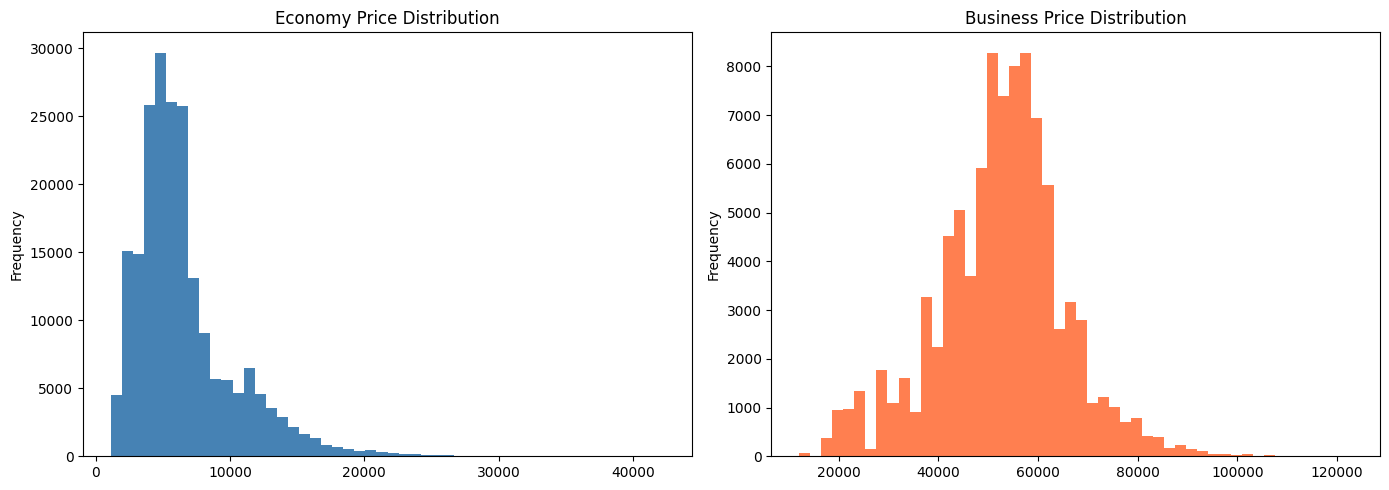

In [10]:
# Price distribution by class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df["class"] == "Economy"]["price"].plot(
    kind="hist",
    bins=50,
    ax=axes[0],
    title="Economy Price Distribution",
    color="steelblue"
)

df[df["class"] == "Business"]["price"].plot(
    kind="hist",
    bins=50,
    ax=axes[1],
    title="Business Price Distribution",
    color="coral"
)

plt.tight_layout()
plt.savefig("../reports/price_distribution.png", dpi=150)
plt.show()


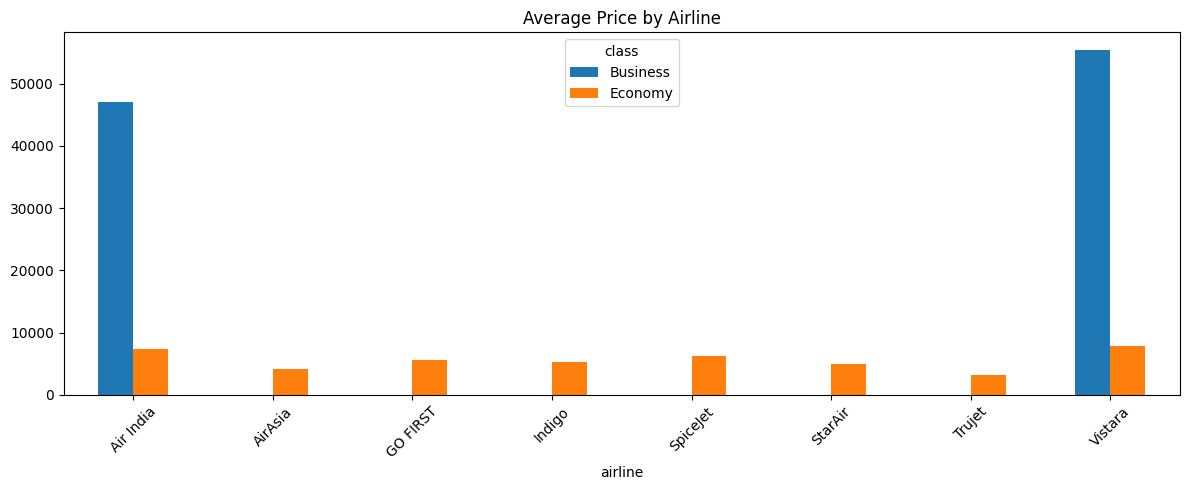

In [11]:
# Average price by airline 

airline_price = (
    df.groupby(["airline", "class"])["price"]
      .mean()
      .unstack()
)

airline_price.plot(
    kind="bar",
    figsize=(12, 5),
    title="Average Price by Airline"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/airline_prices.png", dpi=150)
plt.show()


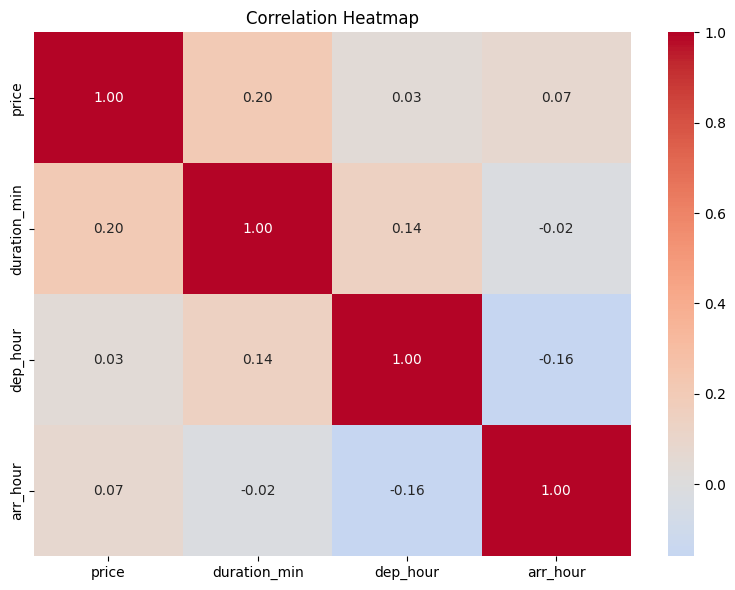

In [12]:
# Correlation heatmap 

numeric_cols = ["price", "duration_min", "dep_hour", "arr_hour"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../reports/correlation_heatmap.png", dpi=150)
plt.show()


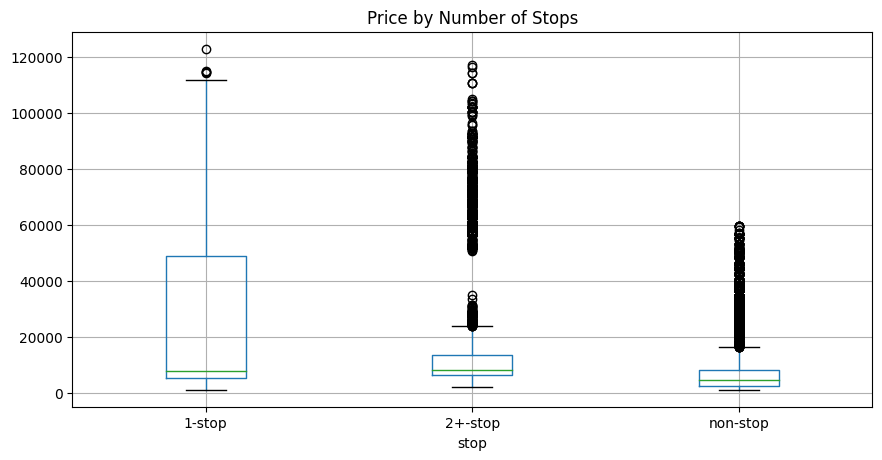

In [13]:
# Price by number of stops 
df.boxplot(column="price", by="stop", figsize=(10, 5)) 
plt.title("Price by Number of Stops") 
plt.suptitle("") 
plt.savefig("../reports/price_by_stops.png", dpi=150) 
plt.show()

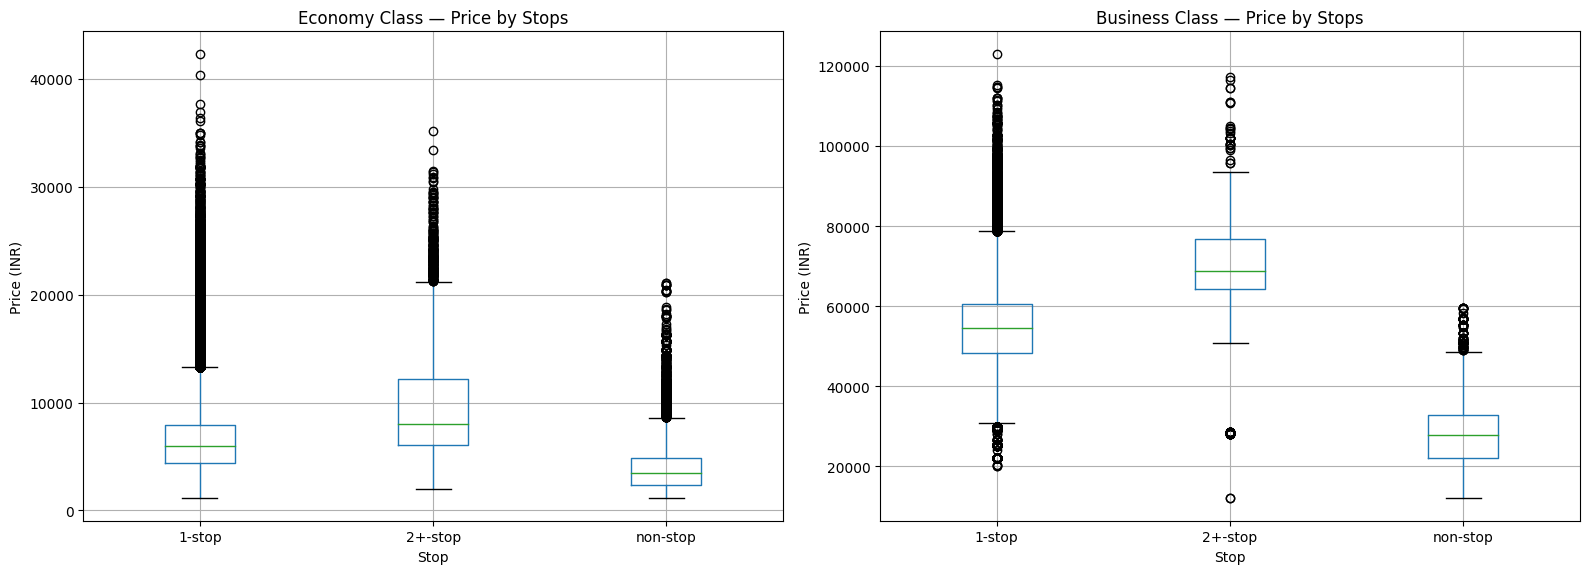

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Economy boxplot
df[df["class"] == "Economy"].boxplot(
    column="price", 
    by="stop", 
    ax=axes[0]
)
axes[0].set_title("Economy Class — Price by Stops")
axes[0].set_xlabel("Stop")
axes[0].set_ylabel("Price (INR)")

# Business boxplot
df[df["class"] == "Business"].boxplot(
    column="price", 
    by="stop", 
    ax=axes[1]
)
axes[1].set_title("Business Class — Price by Stops")
axes[1].set_xlabel("Stop")
axes[1].set_ylabel("Price (INR)")

plt.suptitle("")  # removes automatic title
plt.tight_layout()
plt.savefig("price_by_stops_class.png", dpi=150)
plt.show()

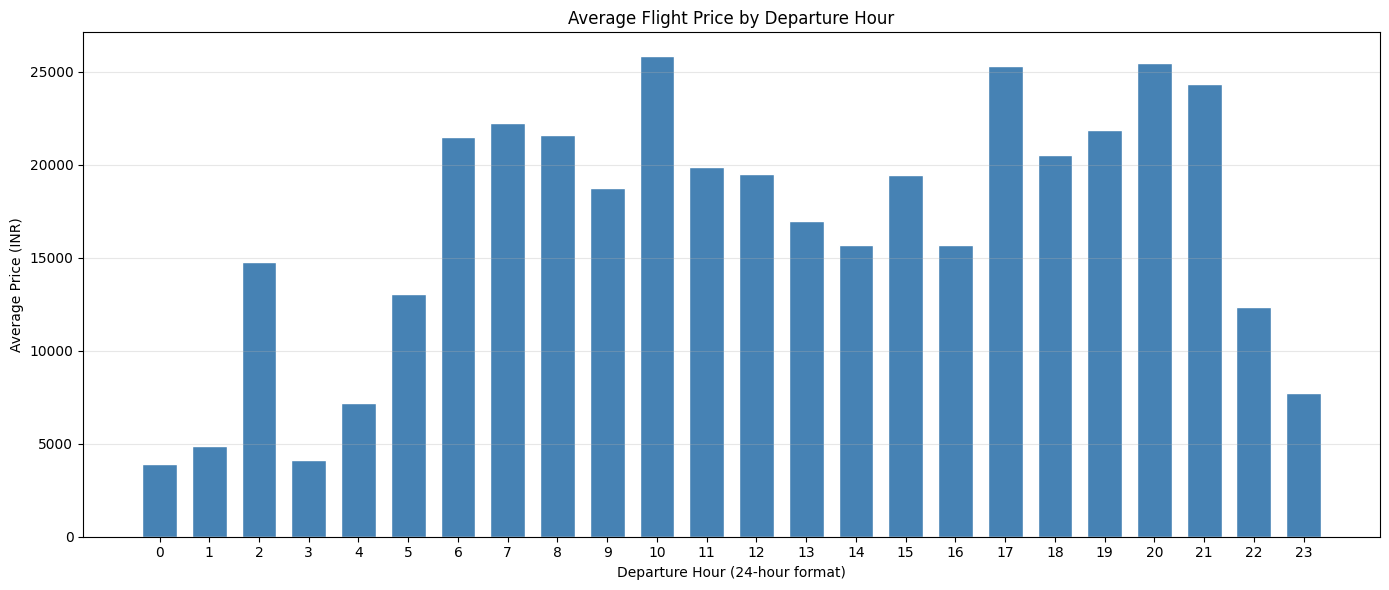

In [15]:
# Check average price for each departure hour
price_by_hour = df.groupby("dep_hour")["price"].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.bar(
    price_by_hour["dep_hour"],   
    price_by_hour["price"],      
    color="steelblue",
    edgecolor="white",
    width=0.7
)

plt.title("Average Flight Price by Departure Hour")
plt.xlabel("Departure Hour (24-hour format)")
plt.ylabel("Average Price (INR)")
plt.xticks(range(0, 24))   
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("price_by_departure_hour.png", dpi=150)
plt.show()

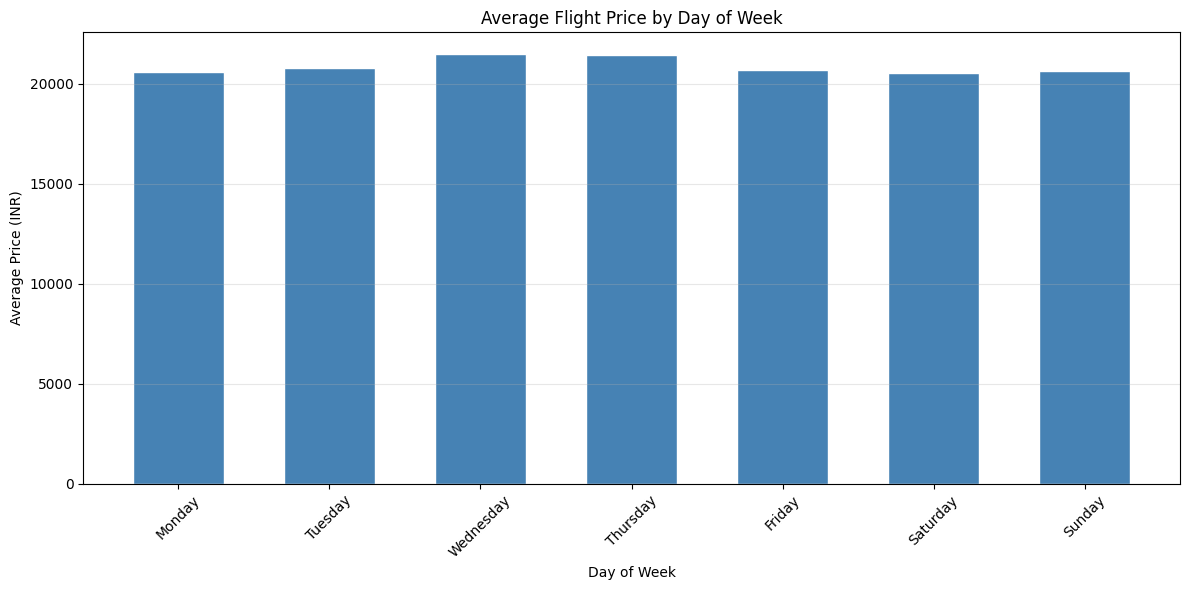

In [17]:
# Check average price for each week day

df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["day_name"] = df["date"].dt.day_name() # Add day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", 
             "Friday", "Saturday", "Sunday"]

price_by_day = df.groupby("day_name")["price"].mean() # Calculate average price per day

price_by_day = price_by_day.reindex(day_order) # Reorder by correct day sequence

plt.figure(figsize=(12, 6))
plt.bar(
    price_by_day.index,    
    price_by_day.values,   
    color="steelblue",
    edgecolor="white",
    width=0.6
)

plt.title("Average Flight Price by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("price_by_weekday.png", dpi=150)
plt.show()
